# IPL 2022 Capstone Project

**The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.**

**These are some of the important columns that we'll focus on for meaningful insights in this project.**

**column names: Variable Type**

* date : string
* venue : string
* stage : string
* team1 : string
* team2 : string
* toss_winner : string
* toss_decision : string
* first_ings_score : integer
* second_ings_score : integer
* match_winner : string
* won_by : string
* margin : integer
* player_of_the_match : string
* top_scorer : string
* highscore : integer
* best_bowling : string
* best_bowling_fgure : string

**Loading the Libraries and Dataset**

In [17]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore") 

df = pd.read_csv("IPL.csv")

df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


**Basic Information**

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

* Check the size of rows and columns of the dataset

In [19]:
print(f"Your rows are {df.shape[0]} and columns are {df.shape[1]}.")

Your rows are 74 and columns are 20.


* Now let's see how many columns have null values in total

In [20]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

**Now, Here comes some Basic Questions**

*   Which team won the most matches?

Text(0.5, 1.0, 'Most matches won ny team')

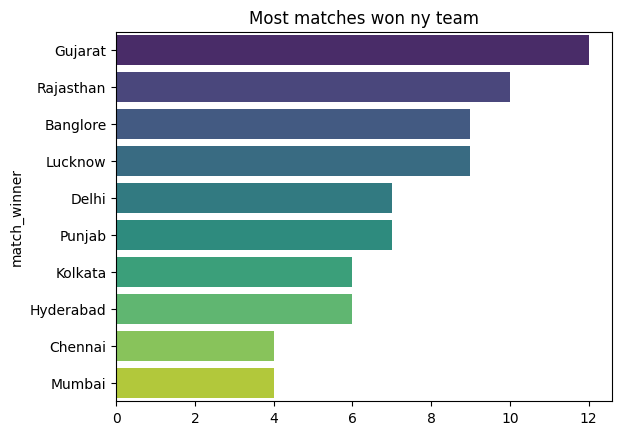

In [24]:
match_wins = df['match_winner'].value_counts()
sns.barplot(y = match_wins.index, x=match_wins.values,palette='viridis')
plt.title("Most matches won ny team")

*   Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trend')

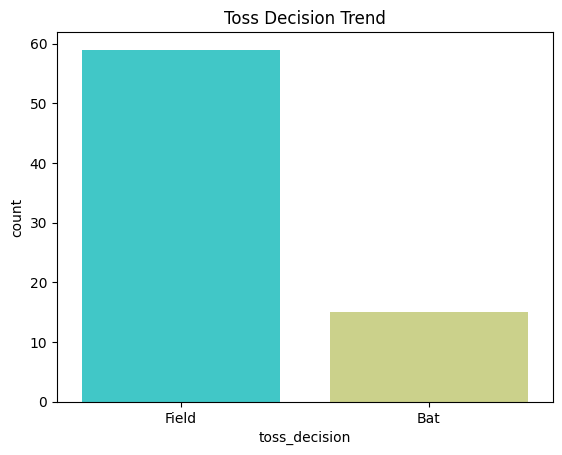

In [27]:
sns.countplot(x = df['toss_decision'],palette='rainbow')
plt.title('Toss Decision Trend')

*   Toss Winner vs Match Winner

In [36]:
toss_match_wins =df[df['toss_winner'] == df['match_winner']]["match_id"].count()
percentage = (toss_match_wins * 100) / df.shape[0]
percentage.round(2)

np.float64(48.65)

*   How do teams win? (Runs vs Wickets)

Text(0.5, 1.0, 'Match Won by Runs vs Wkts')

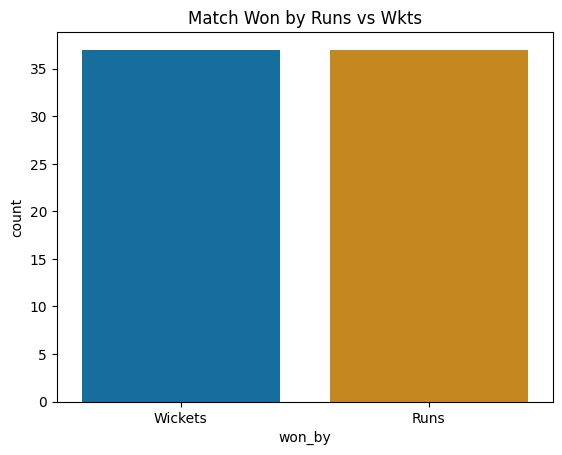

In [41]:
sns.countplot(x = df['won_by'],palette='colorblind')
plt.title("Match Won by Runs vs Wkts")

**Key Player Performances**

*   Most "Player of the Match" Awards

In [49]:
count = df['player_of_the_match'].value_counts().head(10)
count

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 10 Most POTM')

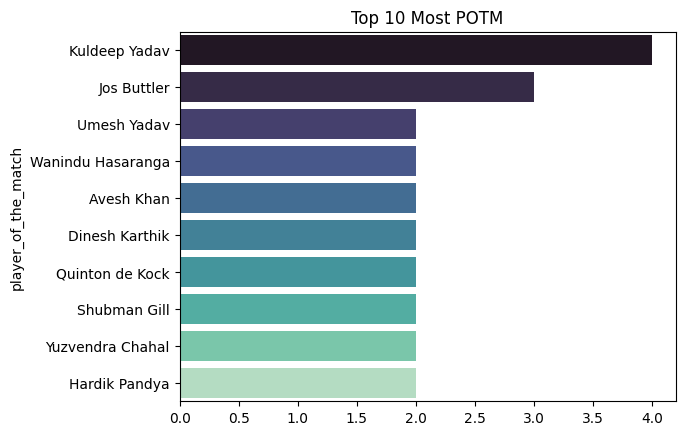

In [51]:
sns.barplot(x = count.values, y = count.index, palette = 'mako')
plt.title("Top 10 Most POTM")

*   Two Top Scorers

In [67]:
# This is if we want the aggregate of all their high scoreing matches
top_score = df.groupby("top_scorer")["highscore"].sum().sort_values(ascending=False).head(2)
top_score

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

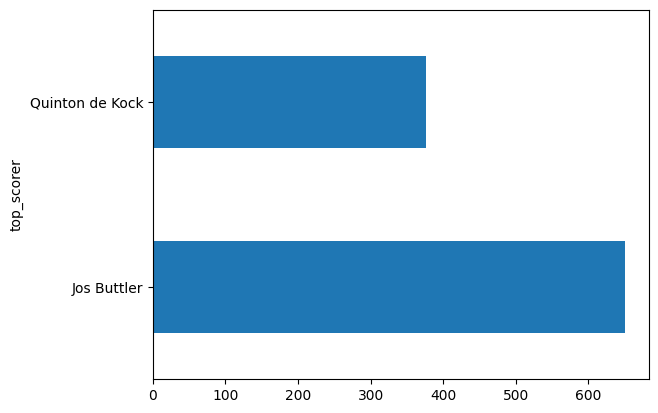

In [69]:
top_score.plot(kind='barh')

In [71]:
# If we wanted the top two high scores
df[['top_scorer','highscore']].nlargest(2,'highscore')

,top_scorer,highscore
65,Quinton de Kock,140
33,Jos Buttler,116


*   10 Best Bowling Figures

In [82]:
df['best_wkts'] = df['best_bowling_figure'].apply(lambda x: int(x.split('--')[0]))
df['least_runs'] = df['best_bowling_figure'].apply(lambda x: int(x.split('--')[1]))
top_10_bowlers = df.sort_values(by=['best_wkts','least_runs'],ascending=[False,True]).head(10)
print(top_10_bowlers[['best_bowling', 'best_bowling_figure']].to_string(index=False))

     best_bowling best_bowling_figure
   Jasprit Bumrah               5--10
Wanindu Hasaranga               5--18
      Umran Malik               5--25
 Yuzvendra Chahal               5--40
    Andre Russell                4--5
    Kuldeep Yadav               4--14
      Mohsin Khan               4--16
Wanindu Hasaranga               4--20
      Kuldeep Sen               4--20
      Umesh Yadav               4--23


**Venue Analysis**

*   Most Matches Played by Venue

In [107]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

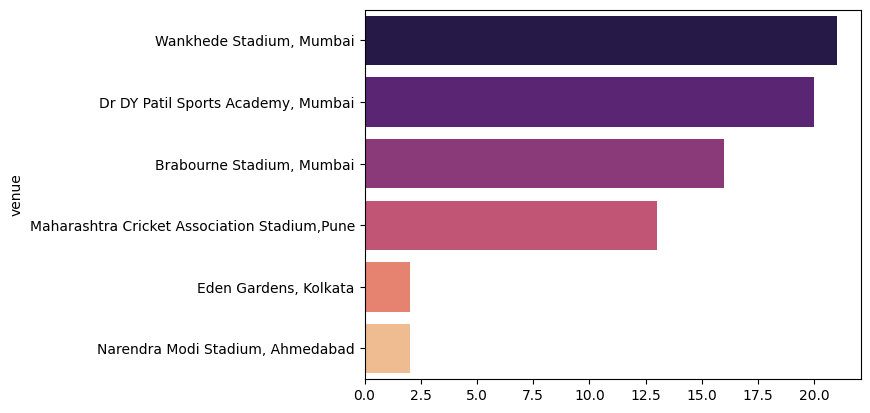

In [106]:
sns.barplot(x= venue_count.values, y = venue_count.index,palette="magma")

**Custom Questions & Insights**

*   Who won by highest runs margin?

In [120]:
by_runs = df[df["won_by"] == 'Runs'].sort_values(by='margin',ascending=False).head(1)
by_runs[["match_winner","won_by","margin"]]

,match_winner,won_by,margin
54,Chennai,Runs,91


*   Which player had the highest individual score?

In [125]:
df[['top_scorer','highscore']].sort_values(by='highscore',ascending=False).head(1)

,top_scorer,highscore
65,Quinton de Kock,140


*   Which bowler had the best bowling figures?

In [128]:
top_10_bowlers[["best_bowling","best_bowling_figure"]].head(1)

,best_bowling,best_bowling_figure
55,Jasprit Bumrah,5--10


# Good Work